# 28 — Comorbidity Analysis: Age-Adjusted & Age-Stratified

**Purpose**: NB27 established that comorbidity burden and disease enrichment escalate with
diabetes severity. A key confound is that more-severe diabetes groups are also older, and
many conditions (cataracts, arthritis, falls, hearing impairment) are fundamentally
age-related. This notebook asks: **after accounting for age, how much of the NB27 enrichment
signal is truly driven by diabetes severity vs. the cohort being older?**

**Self-contained**: Loads directly from Azure — no dependency on prior notebook outputs.
Repeats the same data loading as NB27 and adds age stratification throughout.

**Inputs**:
- Azure `{STUDY_ID}/dataset/participants.tsv` — study group labels
- Azure `{STUDY_ID}/dataset/clinical_data/person.csv` — year_of_birth → age
- Azure `{STUDY_ID}/dataset/clinical_data/observation.csv` — mhoccur survey items

---

**Table of Contents**
1. Environment Setup
2. Azure Connection & Data Load
3. Parse mhoccur Items & Build Master DataFrame
4. Analysis 1 — Age Distribution: Characterising the Confound
5. Analysis 2 — Age-Band-Stratified Disease Prevalence Heatmap
6. Analysis 3 — Age-Adjusted Enrichment via Logistic Regression
7. Analysis 4 — Disease Partitioning: Age-Driven vs Severity-Driven
8. Analysis 5 — Comorbidity Burden Before & After Age Adjustment
9. Key Findings

---

In [1]:
# ── 1. Environment Setup ───────────────────────────────────────────
import subprocess, sys

for pkg in ['azure-storage-blob', 'seaborn', 'scipy', 'python-dotenv', 'statsmodels']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import os, re, warnings, getpass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from io import StringIO
from scipy.stats import fisher_exact, spearmanr, kruskal, mannwhitneyu, chi2_contingency
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
from statsmodels.discrete.discrete_model import Logit
import statsmodels.api as sm

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER   = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP     = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
STUDY_GROUP_STR_MAP = {
    'healthy': 0, 'prediabetes': 1, 'pre-diabetes': 1, 'pre_diabetes': 1,
    'oral medication': 2, 'oral_medication': 2, 'non-insulin': 2,
    'insulin': 3, 'insulin-dependent': 3,
    'pre_diabetes_lifestyle_controlled': 1,
    'oral_medication_and_or_non_insulin_injectable_medication_controlled': 2,
    'insulin_dependent': 3,
}
COMPARISONS  = ['Pre-DM', 'Oral Med', 'Insulin']
COMP_COLORS  = {'Pre-DM': '#4DAFFA', 'Oral Med': '#F5A623', 'Insulin': '#E8413E'}

AGE_BANDS       = ['40–49', '50–59', '60–69', '70+']
AGE_BAND_EDGES  = [0, 50, 60, 70, 120]
AGE_BAND_LABELS = ['<50', '50–59', '60–69', '70+']

STUDY_ID = '1438dd73-c4cb-48b8-8fa8-c858771207c3'

print('Environment ready.')

Environment ready.


In [2]:
# ── 2. Azure Connection & Data Load ──────────────────────────────
from azure.storage.blob import BlobServiceClient
from dotenv import load_dotenv

IN_COLAB = os.path.exists('/content')

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    CONNECTION_STRING = getpass.getpass('CONNECTION_STRING: ')
    CONTAINER_NAME = 'aireadi-container'
else:
    _cwd = Path.cwd()
    if (_cwd / 'config' / 'azure_config.py').exists():
        repo_root = str(_cwd)
    elif (_cwd.parent / 'config' / 'azure_config.py').exists():
        repo_root = str(_cwd.parent)
    else:
        repo_root = str(_cwd)

    _env_path = Path(repo_root) / '.env'
    load_dotenv(_env_path, override=True)
    CONNECTION_STRING = os.getenv('AZURE_STORAGE_CONNECTION_STRING', '')
    CONTAINER_NAME    = os.getenv('AZURE_CONTAINER_NAME', 'aireadi-container')
    STUDY_ID          = os.getenv('AZURE_STUDY_ID', STUDY_ID)
    print(f'.env found={_env_path.exists()}  |  repo_root={repo_root}')
    if not CONNECTION_STRING:
        raise ValueError('AZURE_STORAGE_CONNECTION_STRING empty — check .env')

blob_svc  = BlobServiceClient.from_connection_string(CONNECTION_STRING)
container = blob_svc.get_container_client(CONTAINER_NAME)

def load_blob_csv(blob_path, sep=',', **kwargs):
    bc   = container.get_blob_client(blob_path)
    data = bc.download_blob().readall().decode('utf-8')
    return pd.read_csv(StringIO(data), sep=sep, low_memory=False, **kwargs)

print('\nLoading participants.tsv ...')
participants = load_blob_csv(f'{STUDY_ID}/dataset/participants.tsv', sep='\t')
sg_col = next((c for c in participants.columns if 'study' in c.lower()), None)
participants['study_group_code']  = (participants[sg_col].str.lower()
                                     .str.strip().map(STUDY_GROUP_STR_MAP))
participants['study_group_label'] = participants['study_group_code'].map(STUDY_GROUP_MAP)
participants['study_group_label'] = pd.Categorical(
    participants['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)
print(f'  {len(participants):,} participants')
print(participants['study_group_label'].value_counts().sort_index().to_string())

print('\nLoading person.csv ...')
person = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/person.csv',
                       usecols=['person_id', 'year_of_birth'])
person['age'] = 2024 - person['year_of_birth']

print('\nLoading observation.csv (~108 MB) ...')
obs_raw = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/observation.csv')
print(f'  {len(obs_raw):,} rows × {obs_raw.shape[1]} cols')

.env found=True  |  repo_root=/Users/evanlee/Desktop/ucsf-tech-aireadi

Loading participants.tsv ...
  2,280 participants
study_group_label
Healthy     776
Pre-DM      560
Oral Med    686
Insulin     258

Loading person.csv ...

Loading observation.csv (~108 MB) ...
  707,126 rows × 22 cols


In [3]:
# ── 3. Parse mhoccur Items & Build Master DataFrame ───────────────

obs_raw['item_key']    = (obs_raw['observation_source_value']
                          .astype(str).str.split(',', n=1).str[0]
                          .str.strip().str.lower())
obs_raw['value_clean'] = pd.to_numeric(obs_raw['value_as_number'], errors='coerce')
obs_raw.loc[obs_raw['value_clean'] == 99, 'value_clean'] = np.nan

mh_obs = obs_raw[obs_raw['item_key'].str.startswith('mhoccur', na=False)].copy()
print(f'mhoccur rows: {len(mh_obs):,}  |  unique items: {mh_obs["item_key"].nunique()}')

def clean_label(s):
    if not isinstance(s, str): return str(s)
    s = re.sub(
        r'^(Do you (currently )?have |Have you (ever )?had |'
        r'Have you been (told by a doctor |diagnosed )|'
        r'You have been diagnosed with )',
        '', s, flags=re.IGNORECASE).strip()
    s = s.rstrip('?').strip()
    return s[:1].upper() + s[1:] if s else s

label_map_raw = (mh_obs[['item_key', 'observation_source_value']]
                 .drop_duplicates('item_key')
                 .assign(desc=lambda d: d['observation_source_value']
                                         .str.split(',', n=1).str[1].str.strip()))
label_map = dict(zip(label_map_raw['item_key'],
                     label_map_raw['desc'].apply(clean_label)))

mh_wide = (mh_obs[['person_id', 'item_key', 'value_clean']]
           .pivot_table(index='person_id', columns='item_key',
                        values='value_clean', aggfunc='first')
           .clip(upper=1))

disease_cols = [c for c in mh_wide.columns
                if 'fallot' not in c and c != 'mhoccur_yn']
mh_wide = mh_wide[disease_cols]
print(f'Disease columns: {len(disease_cols)}')

# Merge: participants + age + disease flags
df = (participants[['person_id', 'study_group_code', 'study_group_label']]
      .merge(person[['person_id', 'age']], on='person_id', how='left')
      .merge(mh_wide.reset_index(), on='person_id', how='left'))

df['study_group_label'] = pd.Categorical(
    df['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)

# Age bands
df['age_band'] = pd.cut(
    df['age'], bins=AGE_BAND_EDGES, labels=AGE_BAND_LABELS, right=False)
df['age_band'] = pd.Categorical(df['age_band'], categories=AGE_BAND_LABELS, ordered=True)

df['comorbidity_count'] = df[disease_cols].sum(axis=1, skipna=True)

print(f'\nFinal df: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Age range: {df["age"].min():.0f}–{df["age"].max():.0f}  '
      f'(mean {df["age"].mean():.1f}, median {df["age"].median():.0f})')
print('\nAge band distribution:')
print(df['age_band'].value_counts().sort_index().to_string())

mhoccur rows: 66,486  |  unique items: 30
Disease columns: 28

Final df: 2,280 rows × 34 cols
Age range: 41–94  (mean 61.3, median 62)

Age band distribution:
age_band
<50      420
50–59    564
60–69    719
70+      577


---
## 4. Analysis 1 — Age Distribution: Characterising the Confound

> **Question**: How much older are the more-severe diabetes groups? If the Insulin group
> is substantially older, then enrichments in age-related diseases (cataracts, arthritis,
> cognitive impairment, falls) may be confounded by age rather than reflecting true
> diabetes-driven pathology.
>
> **Method**: Describe age by study group (mean, median, IQR). Run Kruskal-Wallis +
> pairwise comparisons. Visualise age distributions. Compute age band × group cross-tabs.


=== Age Summary by Study Group ===
                     n   mean  median    std    p25    p75
study_group_label                                         
Healthy            776 60.500  60.000 11.600 51.000 69.000
Pre-DM             560 60.800  61.000 11.100 51.000 69.000
Oral Med           686 62.500  63.000 10.500 55.000 70.000
Insulin            258 61.800  62.000 11.600 53.000 70.800

Kruskal-Wallis: H=13.93, p=3.0032e-03

Pairwise Mann-Whitney vs Healthy (Bonferroni × 3):
  Healthy vs Pre-DM      : median 60 vs 61 yr  (Δ=+1)  p_adj=1.0000  ns
  Healthy vs Oral Med    : median 60 vs 63 yr  (Δ=+3)  p_adj=0.0013  **
  Healthy vs Insulin     : median 60 vs 62 yr  (Δ=+2)  p_adj=0.3651  ns

=== Age Band Distribution by Study Group (%) ===
age_band             <50  50–59  60–69    70+
study_group_label                            
Healthy           21.500 25.400 29.400 23.700
Pre-DM            19.100 25.200 31.800 23.900
Oral Med          13.800 24.900 34.100 27.100
Insulin           19.800

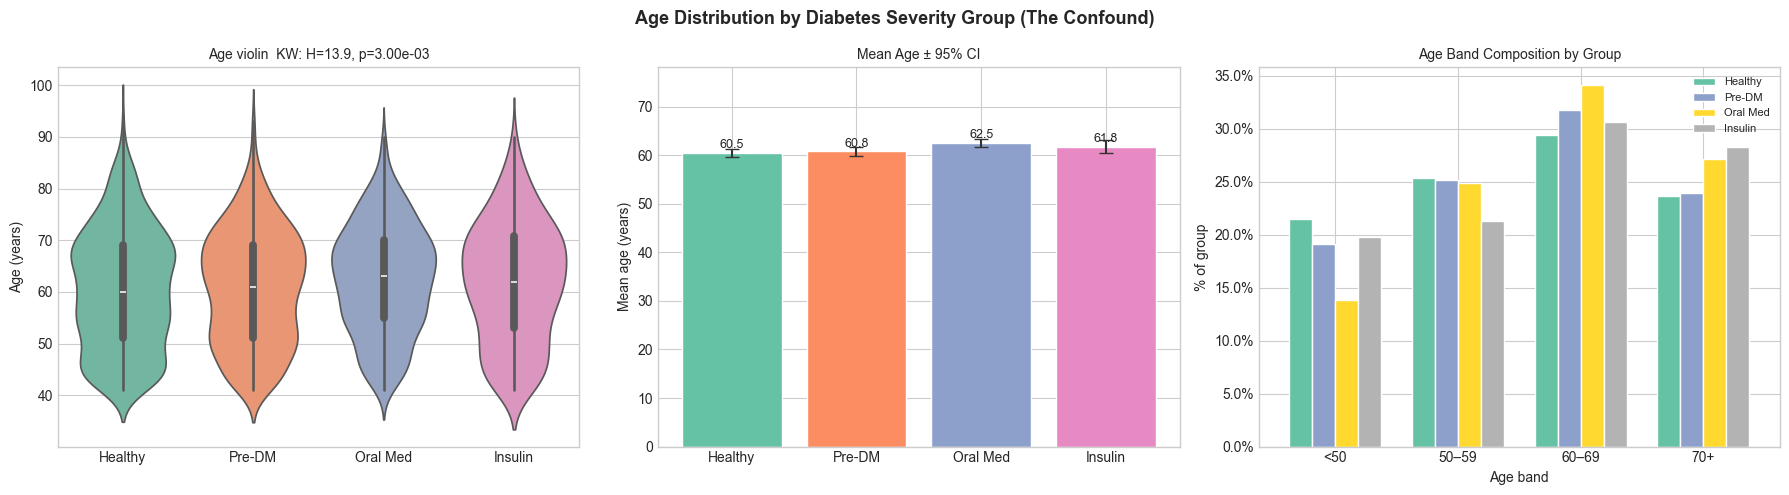

In [4]:
# ── Analysis 1: Age Distribution by Study Group ────────────────────

age_summary = (df.groupby('study_group_label', observed=True)['age']
               .agg(n='count', mean='mean', median='median', std='std',
                    p25=lambda x: x.quantile(0.25),
                    p75=lambda x: x.quantile(0.75))
               .round(1))
print('=== Age Summary by Study Group ===')
print(age_summary.to_string())

# Kruskal-Wallis
grps_age = [df[df['study_group_label'] == g]['age'].dropna() for g in STUDY_GROUP_ORDER]
H_age, p_age = kruskal(*grps_age)
print(f'\nKruskal-Wallis: H={H_age:.2f}, p={p_age:.4e}')

print('\nPairwise Mann-Whitney vs Healthy (Bonferroni × 3):')
healthy_age = df[df['study_group_label'] == 'Healthy']['age'].dropna()
for grp in COMPARISONS:
    grp_age = df[df['study_group_label'] == grp]['age'].dropna()
    _, p_mw = mannwhitneyu(healthy_age, grp_age, alternative='two-sided')
    p_adj   = min(1.0, p_mw * 3)
    sig     = '***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*' if p_adj < 0.05 else 'ns'
    print(f'  Healthy vs {grp:<12}: '
          f'median {healthy_age.median():.0f} vs {grp_age.median():.0f} yr  '
          f'(Δ={grp_age.median() - healthy_age.median():+.0f})  p_adj={p_adj:.4f}  {sig}')

# Age band × group cross-tab
print('\n=== Age Band Distribution by Study Group (%) ===')
band_ct = (df.groupby(['study_group_label', 'age_band'], observed=True)
             .size().unstack(fill_value=0))
band_pct = band_ct.div(band_ct.sum(axis=1), axis=0) * 100
print(band_pct.round(1).to_string())

# Chi-square on band composition
chi2, p_chi, _, _ = chi2_contingency(band_ct.values)
print(f'\nChi-square (age band × group): χ²={chi2:.2f}, p={p_chi:.4e}')

# ── Visualisation ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Age Distribution by Diabetes Severity Group (The Confound)',
             fontsize=13, fontweight='bold')

# Panel A: violin
sns.violinplot(data=df, x='study_group_label', y='age',
               order=STUDY_GROUP_ORDER, palette='Set2', inner='box', ax=axes[0])
axes[0].set_title(f'Age violin  KW: H={H_age:.1f}, p={p_age:.2e}', fontsize=10)
axes[0].set_xlabel('')
axes[0].set_ylabel('Age (years)')

# Panel B: mean age with 95% CI
means_age  = age_summary['mean'].values
sds_age    = age_summary['std'].values
ns_age     = age_summary['n'].values
ses_age    = sds_age / np.sqrt(ns_age)
colors_sg  = sns.color_palette('Set2', 4)
bars = axes[1].bar(STUDY_GROUP_ORDER, means_age, color=colors_sg, edgecolor='white')
axes[1].errorbar(STUDY_GROUP_ORDER, means_age, yerr=1.96 * ses_age,
                 fmt='none', color='#333', capsize=5)
for bar, m in zip(bars, means_age):
    axes[1].text(bar.get_x() + bar.get_width() / 2, m + 1,
                 f'{m:.1f}', ha='center', fontsize=9)
axes[1].set_ylabel('Mean age (years)')
axes[1].set_title('Mean Age ± 95% CI', fontsize=10)
axes[1].set_ylim(0, max(means_age) * 1.25)

# Panel C: stacked age band bar
band_pct.T.plot(kind='bar', ax=axes[2], colormap='Set2', edgecolor='white', width=0.75)
axes[2].set_xlabel('Age band')
axes[2].set_ylabel('% of group')
axes[2].set_title('Age Band Composition by Group', fontsize=10)
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[2].legend(title='', fontsize=8)
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

---
## 5. Analysis 2 — Age-Band-Stratified Disease Prevalence Heatmap

> **Question**: Within each age band, how does disease prevalence compare across diabetes
> severity groups? If a disease enrichment in NB27 was purely age-driven, it should
> *disappear* or *flatten* when we hold age constant by looking within a single age band.
>
> **Method**: For each of the 20 most prevalent diseases, compute prevalence at every
> group × age-band combination (16 cells). Display as a 20-disease × 16-cell heatmap.
> Diseases that remain enriched in higher-severity groups within each age band are
> truly severity-driven.


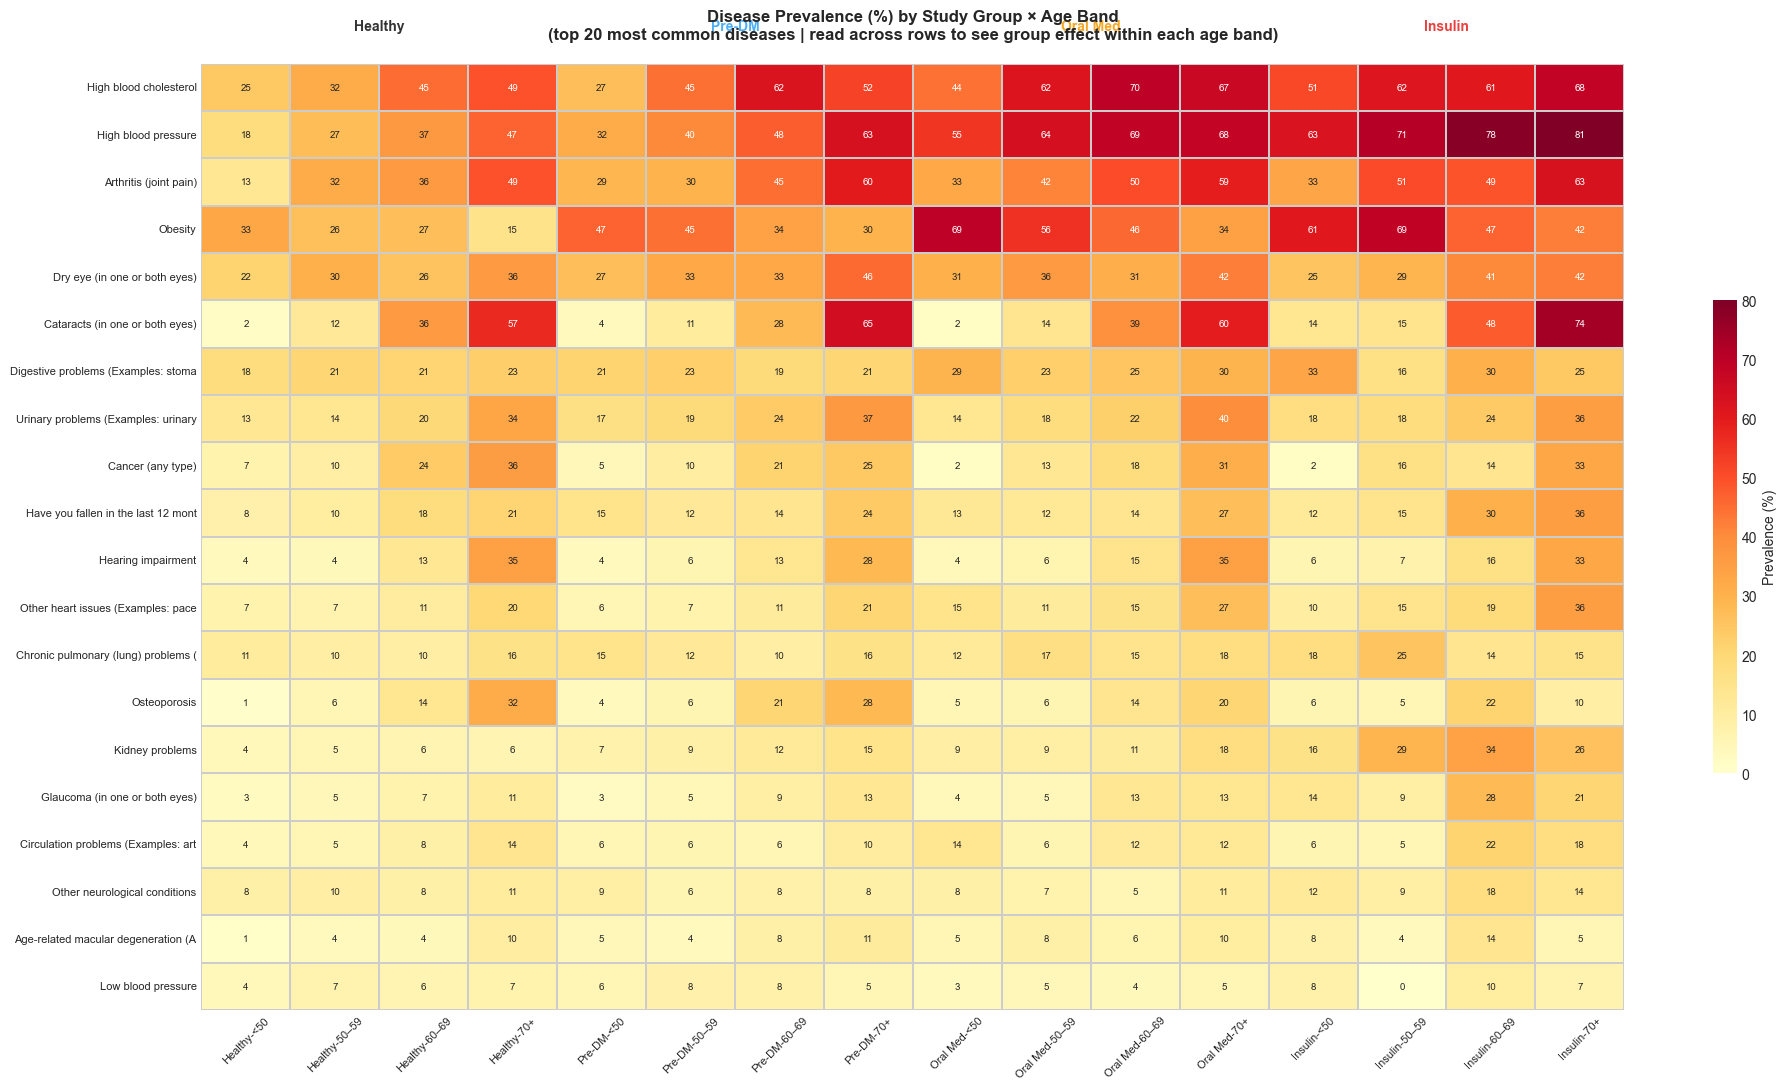

In [5]:
# ── Analysis 2: Age-Band × Group Prevalence Heatmap ───────────────

# Select top-20 most prevalent diseases for readability
top20_cols = (df[disease_cols].mean(skipna=True)
              .sort_values(ascending=False).head(20).index.tolist())
top20_labels = [label_map.get(c, c)[:35] for c in top20_cols]

# Compute prevalence for each disease × group × age band
prev_records = []
for col, lbl in zip(top20_cols, top20_labels):
    for grp in STUDY_GROUP_ORDER:
        for band in AGE_BAND_LABELS:
            sub = df[(df['study_group_label'] == grp) & (df['age_band'] == band)]
            n   = sub[col].count()
            pos = sub[col].sum(skipna=True)
            prev = (pos / n * 100) if n >= 5 else np.nan
            prev_records.append({'disease': lbl, 'col': col,
                                 'group': grp, 'age_band': band,
                                 'prev_pct': prev, 'n': n})

prev_df = pd.DataFrame(prev_records)

# Build heatmap pivot: rows = diseases, cols = (group, age_band)
prev_pivot = prev_df.pivot_table(
    index='disease', columns=['group', 'age_band'],
    values='prev_pct', aggfunc='first')

# Reorder columns to be group-major, then age-band
col_order = [(g, b) for g in STUDY_GROUP_ORDER for b in AGE_BAND_LABELS]
prev_pivot = prev_pivot.reindex(columns=col_order)

# Order rows by overall prevalence
row_order = (df[top20_cols].mean(skipna=True)
             .sort_values(ascending=False)
             .index.map(lambda c: label_map.get(c, c)[:35]))
prev_pivot = prev_pivot.reindex(index=row_order)

fig, ax = plt.subplots(figsize=(20, 11))
sns.heatmap(
    prev_pivot, annot=True, fmt='.0f', cmap='YlOrRd',
    vmin=0, vmax=80, linewidths=0.3, linecolor='#cccccc',
    annot_kws={'size': 7}, ax=ax,
    cbar_kws={'label': 'Prevalence (%)', 'shrink': 0.5}
)

# Column group headers
for i, grp in enumerate(STUDY_GROUP_ORDER):
    ax.text(i * len(AGE_BAND_LABELS) + len(AGE_BAND_LABELS) / 2, -0.8,
            grp, ha='center', va='center', fontsize=10,
            fontweight='bold', color=COMP_COLORS.get(grp, '#333'))

ax.set_title(
    'Disease Prevalence (%) by Study Group × Age Band\n'
    '(top 20 most common diseases | read across rows to see group effect within each age band)',
    fontsize=12, fontweight='bold', pad=18
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', labelsize=8, rotation=45)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

---
## 6. Analysis 3 — Age-Adjusted Enrichment via Logistic Regression

> **Question**: What are the odds ratios for each disease in Pre-DM, Oral Med, and Insulin
> groups after controlling for age? How much do the crude ORs from NB27 shrink?
>
> **Method**: For each disease, fit a logistic regression:
> `disease_flag ~ group_dummy_PreDM + group_dummy_OralMed + group_dummy_Insulin + age`
> Extract the exponentiated coefficients (adjusted ORs) and compare to NB27 crude ORs.
> Large shrinkage = age was confounding. Small shrinkage = true severity effect.


In [6]:
# ── Analysis 3: Age-Adjusted Logistic Regression ──────────────────

# Create dummies (Healthy = reference)
df_reg = df[['study_group_label', 'study_group_code', 'age'] + disease_cols].copy()
df_reg = pd.get_dummies(df_reg, columns=['study_group_label'], drop_first=False)
df_reg['age_std'] = (df_reg['age'] - df_reg['age'].mean()) / df_reg['age'].std()

# Crude ORs from NB27 (1/OR because NB27 reports as Healthy/Group)
NB27_CRUDE = {
    'mhoccur_hbp':  {'Pre-DM': 1/0.557, 'Oral Med': 1/0.255, 'Insulin': 1/0.167},
    'mhoccur_pdr':  {'Pre-DM': 1/1.000, 'Oral Med': 1/0.050, 'Insulin': 1/0.014},
    'mhoccur_obs':  {'Pre-DM': 1/0.546, 'Oral Med': 1/0.360, 'Insulin': 1/0.298},
    'mhoccur_clsh': {'Pre-DM': 1/0.655, 'Oral Med': 1/0.360, 'Insulin': 1/0.395},
    'mhoccur_rnl':  {'Pre-DM': 1/0.468, 'Oral Med': 1/0.410, 'Insulin': 1/0.154},
    'mhoccur_mi':   {'Pre-DM': 1/1.000, 'Oral Med': 1/0.356, 'Insulin': 1/0.186},
    'mhoccur_oa':   {'Pre-DM': 1/0.703, 'Oral Med': 1/0.540, 'Insulin': 1/0.493},
    'mhoccur_glc':  {'Pre-DM': 1/1.000, 'Oral Med': 1/0.636, 'Insulin': 1/0.294},
    'mhoccur_crt':  {'Pre-DM': 1/1.000, 'Oral Med': 1/0.770, 'Insulin': 1/0.541},
    'mhoccur_fall': {'Pre-DM': 1/1.000, 'Oral Med': 1/1.000, 'Insulin': 1/0.517},
    'mhoccur_cogn': {'Pre-DM': 1/1.000, 'Oral Med': 1/1.000, 'Insulin': 1/0.359},
    'mhoccur_strk': {'Pre-DM': 1/1.000, 'Oral Med': 1/1.000, 'Insulin': 1/0.371},
    'mhoccur_ear':  {'Pre-DM': 1/1.000, 'Oral Med': 1/1.000, 'Insulin': 1/1.000},
    'mhoccur_plm':  {'Pre-DM': 1/1.000, 'Oral Med': 1/0.692, 'Insulin': 1/0.605},
    'mhoccur_amd':  {'Pre-DM': 1/1.000, 'Oral Med': 1/0.581, 'Insulin': 1/1.000},
    'mhoccur_cvdot': {'Pre-DM': 1/1.000, 'Oral Med': 1/1.000, 'Insulin': 1/0.535},
    'mhoccur_rvo':  {'Pre-DM': 1/1.000, 'Oral Med': 1/1.000, 'Insulin': 1/0.349},
}

# Reference group: Healthy
REF_GROUP = 'study_group_label_Healthy'

adj_records = []
for col in disease_cols:
    label = label_map.get(col, col)[:40]
    sub   = df_reg[['age_std', col,
                    'study_group_label_Pre-DM',
                    'study_group_label_Oral Med',
                    'study_group_label_Insulin']].dropna()
    if sub[col].sum() < 10 or sub[col].sum() == len(sub):
        continue
    try:
        X = sm.add_constant(sub[['study_group_label_Pre-DM',
                                  'study_group_label_Oral Med',
                                  'study_group_label_Insulin',
                                  'age_std']])
        logit_res = sm.Logit(sub[col].astype(float), X.astype(float)).fit(
            disp=False, maxiter=200)
        for grp_dummy, grp_name in [
            ('study_group_label_Pre-DM',  'Pre-DM'),
            ('study_group_label_Oral Med', 'Oral Med'),
            ('study_group_label_Insulin',  'Insulin'),
        ]:
            coef = logit_res.params[grp_dummy]
            pval = logit_res.pvalues[grp_dummy]
            adj_or = np.exp(coef)
            crude_or = NB27_CRUDE.get(col, {}).get(grp_name, np.nan)
            adj_records.append({
                'col': col, 'label': label,
                'comparison': grp_name,
                'adj_or': round(adj_or, 3),
                'p_adj_logit': round(pval, 5),
                'crude_or_nb27': round(crude_or, 3) if not np.isnan(crude_or) else np.nan,
                'or_shrinkage': round(
                    (crude_or - adj_or) / crude_or * 100, 1
                ) if not np.isnan(crude_or) and crude_or > 1 else np.nan,
            })
    except Exception as e:
        print(f'  Logit failed for {col}: {e}')
        continue

adj_df = pd.DataFrame(adj_records)

# FDR correction across all tests per comparison
fdr_parts = []
for grp in COMPARISONS:
    sub = adj_df[adj_df['comparison'] == grp].copy()
    if len(sub) == 0:
        continue
    _, sub['p_fdr'], _, _ = multipletests(sub['p_adj_logit'], method='fdr_bh')
    fdr_parts.append(sub)
adj_df = pd.concat(fdr_parts).reset_index(drop=True)
adj_df['significant_adj'] = adj_df['p_fdr'] < 0.05

print('=== AGE-ADJUSTED ENRICHMENT (top results per group) ===')
for grp in COMPARISONS:
    top = (adj_df[(adj_df['comparison'] == grp) & (adj_df['adj_or'] > 1)]
           .sort_values('adj_or', ascending=False).head(12))
    print(f'\n── {grp} vs Healthy (age-adjusted) ──')
    print(top[['label', 'crude_or_nb27', 'adj_or', 'or_shrinkage', 'p_fdr', 'significant_adj']]
          .to_string(index=False))

=== AGE-ADJUSTED ENRICHMENT (top results per group) ===

── Pre-DM vs Healthy (age-adjusted) ──
                                label  crude_or_nb27  adj_or  or_shrinkage  p_fdr  significant_adj
 Diabetic retinopathy (in one or both          1.000   2.782           NaN  0.366            False
                      Kidney problems          2.137   2.135         0.100  0.002             True
  Mild cognitive impairment (known as          1.000   2.052           NaN  0.083            False
                              Obesity          1.832   1.891        -3.300  0.000             True
                  High blood pressure          1.795   1.814        -1.000  0.000             True
 Age-related macular degeneration (AM          1.000   1.580           NaN  0.183            False
               High blood cholesterol          1.527   1.531        -0.300  0.002             True
               Arthritis (joint pain)            NaN   1.435           NaN  0.012             True
        Dry e

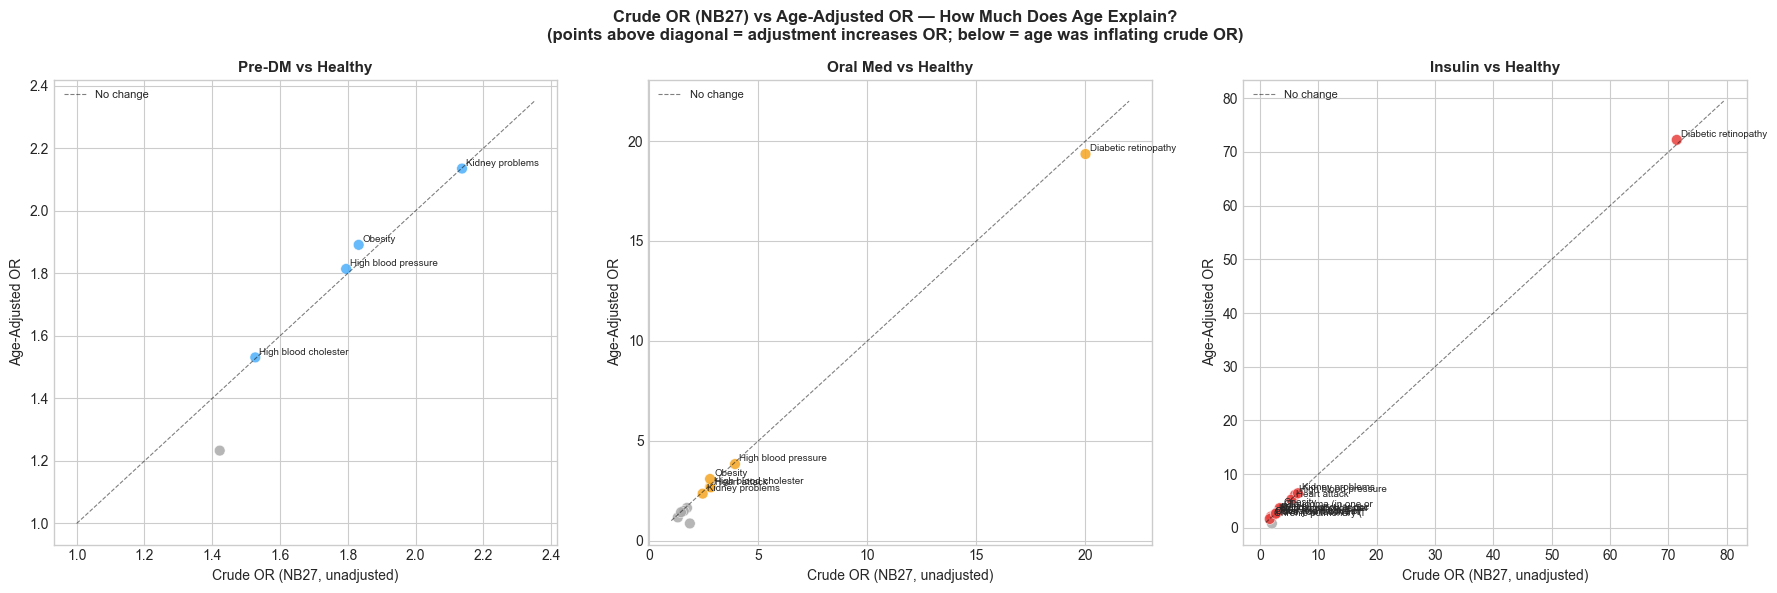

In [7]:
# ── Plot 3: Crude vs Adjusted OR Scatter ────────────────────────────
plot_data = adj_df[adj_df['crude_or_nb27'].notna() &
                   (adj_df['crude_or_nb27'] > 1) &
                   (adj_df['adj_or'] > 0)].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Crude OR (NB27) vs Age-Adjusted OR — How Much Does Age Explain?\n'
             '(points above diagonal = adjustment increases OR; below = age was inflating crude OR)',
             fontsize=12, fontweight='bold')

for ax, grp in zip(axes, COMPARISONS):
    sub = plot_data[plot_data['comparison'] == grp].copy()
    if sub.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue

    colors_pt = sub['significant_adj'].map({True: COMP_COLORS[grp], False: '#aaaaaa'})
    ax.scatter(sub['crude_or_nb27'], sub['adj_or'],
               c=colors_pt, s=60, alpha=0.85, edgecolors='white', linewidths=0.4)

    # Diagonal (no change)
    lim_max = max(sub['crude_or_nb27'].max(), sub['adj_or'].max()) * 1.1
    ax.plot([1, lim_max], [1, lim_max], 'k--', linewidth=0.8, alpha=0.5, label='No change')

    # Label significantly enriched points
    for _, row in sub[sub['significant_adj'] & (sub['adj_or'] > 1)].iterrows():
        ax.annotate(row['label'][:20],
                    xy=(row['crude_or_nb27'], row['adj_or']),
                    xytext=(3, 2), textcoords='offset points', fontsize=7)

    ax.set_xlabel('Crude OR (NB27, unadjusted)', fontsize=10)
    ax.set_ylabel('Age-Adjusted OR', fontsize=10)
    ax.set_title(f'{grp} vs Healthy', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## 7. Analysis 4 — Disease Partitioning: Age-Driven vs Severity-Driven

> **Classification criteria** (applied to the Insulin group, the most extreme comparison):
>
> - **Severity-driven**: adjusted OR remains significant (FDR < 0.05) AND shrinkage < 30%
>   (age adjustment changes the OR by less than 30% — the disease is truly linked to severity)
> - **Age-driven**: crude OR was elevated but adjusted OR drops below 1.5 or loses significance;
>   OR shrinkage ≥ 50%
> - **Both**: significant after adjustment but shrinkage 30–50% (shared age + severity effects)
> - **Neither**: not significant in either crude or adjusted analysis


=== DISEASE PARTITIONING (Insulin vs Healthy) ===

── Severity-driven (14 diseases) ──
                               label  crude_or_nb27  adj_or  or_shrinkage  p_fdr  significant_adj
Diabetic retinopathy (in one or both         71.429  72.251        -1.200  0.000             True
                     Kidney problems          6.494   6.427         1.000  0.000             True
                 High blood pressure          5.988   6.109        -2.000  0.000             True
                        Heart attack          5.376   5.260         2.200  0.000             True
                             Obesity          3.356   3.650        -8.800  0.000             True
      Glaucoma (in one or both eyes)          3.401   3.339         1.800  0.000             True
 Retinal vascular occlusion ("stroke          2.865   2.783         2.900  0.022             True
 Mild cognitive impairment (known as          2.786   2.688         3.500  0.011             True
                              S

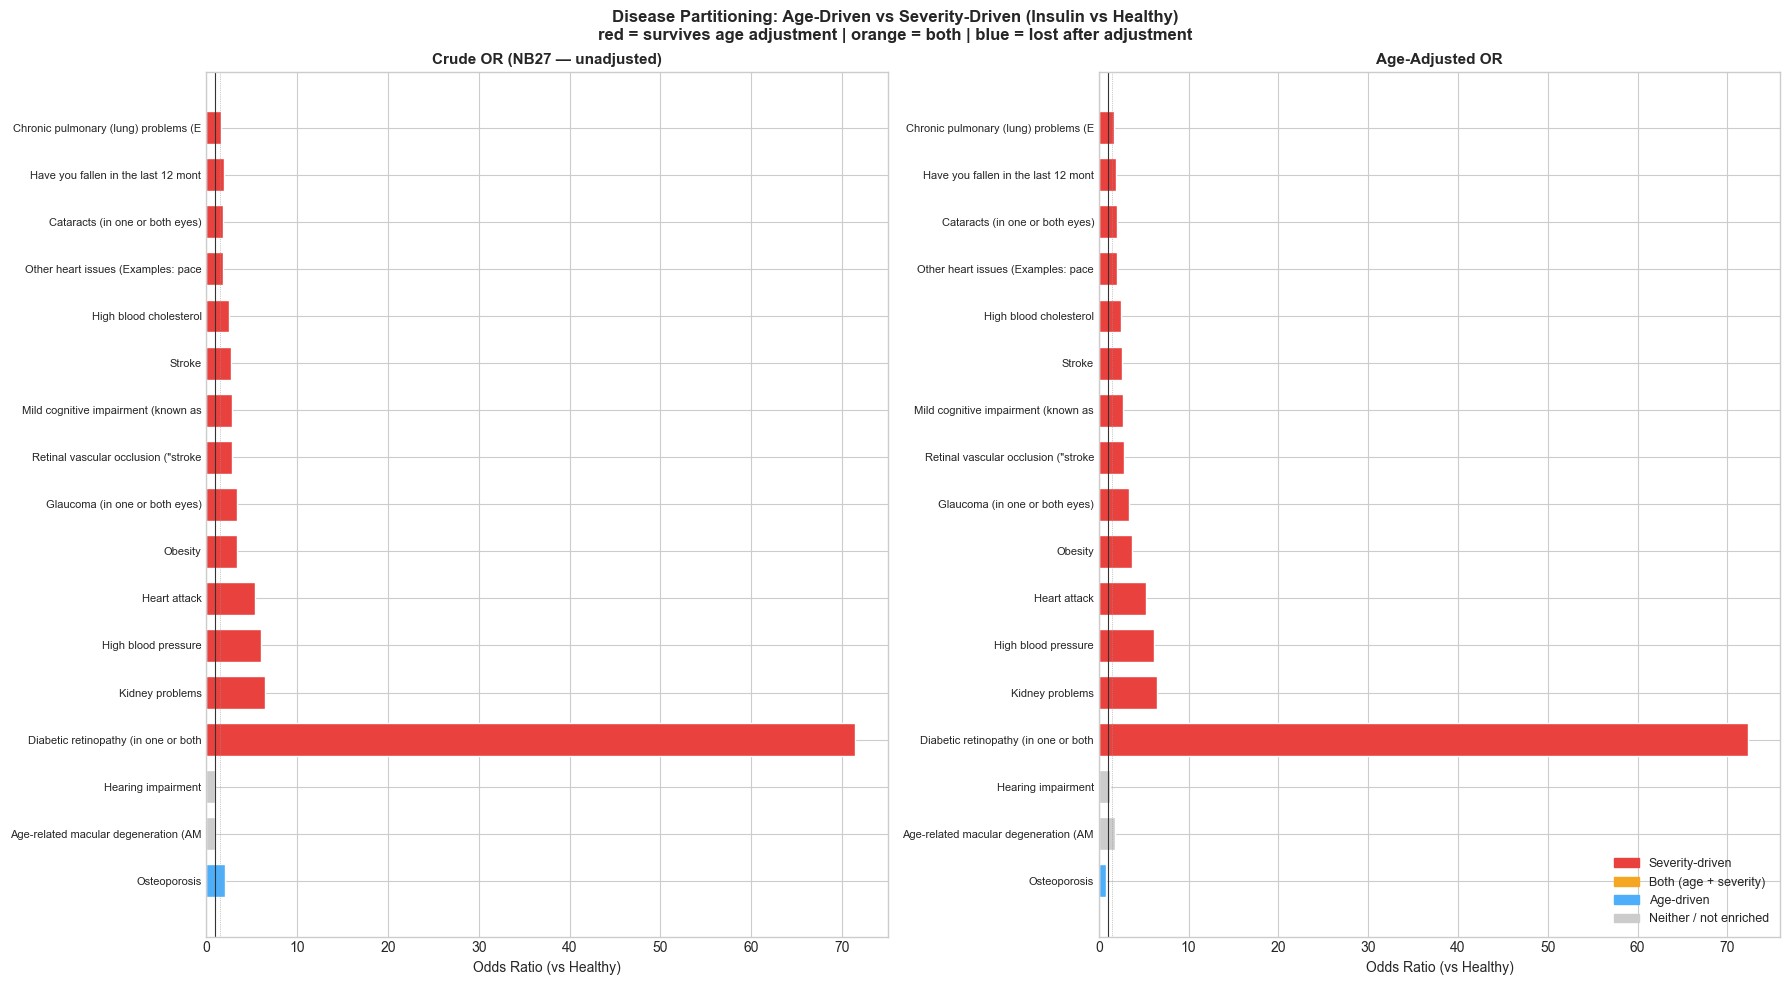

In [8]:
# ── Analysis 4: Disease Partitioning ────────────────────────────────

# Focus on Insulin comparison (most informative — biggest age gap)
ins_adj = adj_df[adj_df['comparison'] == 'Insulin'].copy()

def classify_disease(row):
    crude = row['crude_or_nb27']
    adj   = row['adj_or']
    sig   = row['significant_adj']
    shrink = row['or_shrinkage']  # % drop from crude to adj

    if pd.isna(crude) or crude <= 1:
        return 'Neither / not enriched'
    if sig and (pd.isna(shrink) or shrink < 30):
        return 'Severity-driven'
    if sig and not pd.isna(shrink) and 30 <= shrink < 50:
        return 'Both (age + severity)'
    if not sig or (not pd.isna(shrink) and shrink >= 50):
        return 'Age-driven'
    return 'Neither / not enriched'

ins_adj['category'] = ins_adj.apply(classify_disease, axis=1)

print('=== DISEASE PARTITIONING (Insulin vs Healthy) ===')
for cat in ['Severity-driven', 'Both (age + severity)', 'Age-driven', 'Neither / not enriched']:
    sub = ins_adj[ins_adj['category'] == cat][['label', 'crude_or_nb27', 'adj_or',
                                                 'or_shrinkage', 'p_fdr', 'significant_adj']]
    print(f'\n── {cat} ({len(sub)} diseases) ──')
    if len(sub) > 0:
        print(sub.sort_values('adj_or', ascending=False).to_string(index=False))

# ── Visualisation: horizontal bar chart partitioned by category ───
cat_colors = {
    'Severity-driven':         '#E8413E',
    'Both (age + severity)':   '#F5A623',
    'Age-driven':              '#4DAFFA',
    'Neither / not enriched':  '#cccccc',
}

plot_part = ins_adj[ins_adj['crude_or_nb27'].notna()].copy()
plot_part = plot_part.sort_values(['category', 'adj_or'], ascending=[True, False])

fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle('Disease Partitioning: Age-Driven vs Severity-Driven (Insulin vs Healthy)\n'
             'red = survives age adjustment | orange = both | blue = lost after adjustment',
             fontsize=12, fontweight='bold')

# Panel A: Adjusted ORs colored by category
for ax, or_col, title in zip(
    axes,
    ['crude_or_nb27', 'adj_or'],
    ['Crude OR (NB27 — unadjusted)', 'Age-Adjusted OR']
):
    colors_bar = [cat_colors[c] for c in plot_part['category']]
    bars = ax.barh(plot_part['label'], plot_part[or_col],
                   color=colors_bar, edgecolor='white', height=0.7)
    ax.axvline(1, color='#333', linewidth=0.8)
    ax.axvline(1.5, color='#999', linewidth=0.5, linestyle=':')
    ax.set_xlabel('Odds Ratio (vs Healthy)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=l) for l, c in cat_colors.items()]
axes[1].legend(handles=legend_handles, fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

---
## 8. Analysis 5 — Comorbidity Burden Before & After Age Adjustment

> **Question**: Does the escalating comorbidity burden gradient from NB27 (Healthy median=3,
> Pre-DM=4, Oral Med=5, Insulin=6) persist after controlling for age?
>
> **Method**: OLS regression: `comorbidity_count ~ study_group_code + age`.
> Compare R² and group coefficients with and without age in the model.
> Then re-examine the burden gradient after residualizing for age.


=== Model A: comorbidity_count ~ study_group_code ===
  R²=0.0789  group_coef=0.844  p=1.3249e-42

=== Model B: comorbidity_count ~ study_group_code + age ===
  R²=0.2217
  study_group_code: coef=0.771  p=5.1414e-42
  age (std):        coef=1.170  p=2.2392e-85
  Variance explained by age alone: 0.1428 (64.4% of total R²)

=== Model C: comorbidity_count ~ study_group_code * age_std (interaction) ===
  R²=0.2220  (vs additive Model B R²=0.2217, gain=+0.0003)
  study_group_code (main):    coef=+0.771  p=5.0649e-42
  age_std (main):             coef=+1.229  p=9.7050e-46
  group × age (INTERACTION):  coef=-0.051  p=3.5036e-01
  -> Not significant: the per-step severity effect on burden is consistent across all ages (the simpler additive model holds).

=== Burden gradient after removing age effect (mean residuals) ===
  Healthy     : mean residual = -0.850  (n=776)
  Pre-DM      : mean residual = -0.208  (n=560)
  Oral Med    : mean residual = +0.522  (n=686)
  Insulin     : mean residual = 

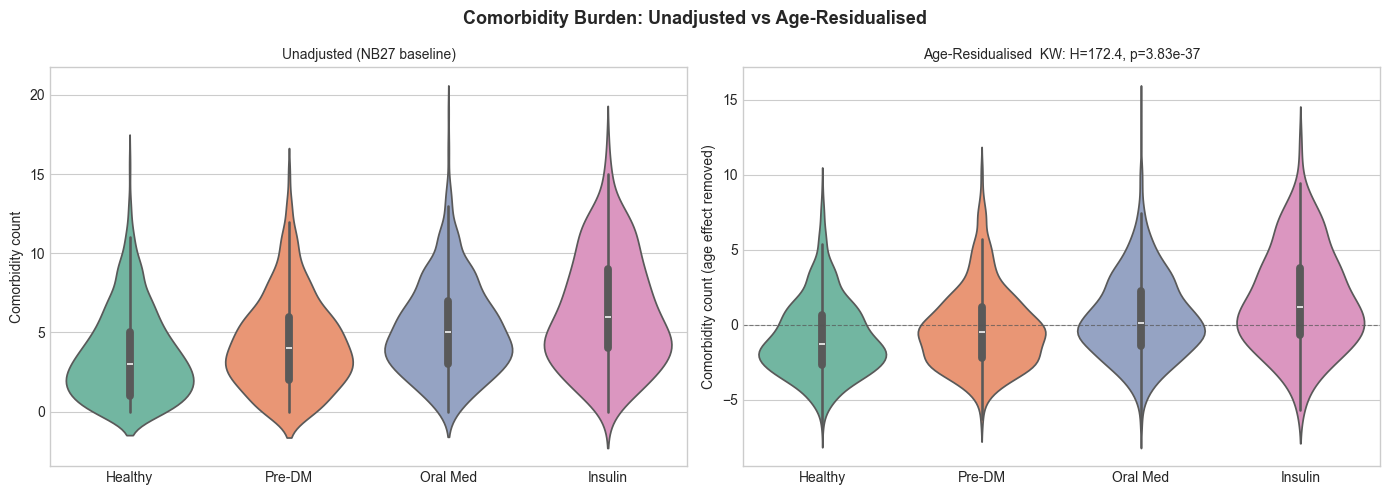

In [9]:
# ── Analysis 5: Burden Before & After Age Adjustment ────────────────

df_ols = df[['comorbidity_count', 'study_group_code', 'age']].dropna()
df_ols['age_std'] = (df_ols['age'] - df_ols['age'].mean()) / df_ols['age'].std()

# Model A: burden ~ group only (NB27 baseline)
model_a = smf.ols('comorbidity_count ~ study_group_code', data=df_ols).fit()

# Model B: burden ~ group + age
model_b = smf.ols('comorbidity_count ~ study_group_code + age_std', data=df_ols).fit()

print('=== Model A: comorbidity_count ~ study_group_code ===')
print(f'  R²={model_a.rsquared:.4f}  group_coef={model_a.params["study_group_code"]:.3f}  '
      f'p={model_a.pvalues["study_group_code"]:.4e}')

print('\n=== Model B: comorbidity_count ~ study_group_code + age ===')
print(f'  R²={model_b.rsquared:.4f}')
print(f'  study_group_code: coef={model_b.params["study_group_code"]:.3f}  '
      f'p={model_b.pvalues["study_group_code"]:.4e}')
print(f'  age (std):        coef={model_b.params["age_std"]:.3f}  '
      f'p={model_b.pvalues["age_std"]:.4e}')
print(f'  Variance explained by age alone: '
      f'{model_b.rsquared - model_a.rsquared:.4f} ({(model_b.rsquared - model_a.rsquared)/model_b.rsquared*100:.1f}% of total R²)')

# Model C: burden ~ group × age  (interaction — does the severity effect depend on age?)
# The * expands to group + age + group:age. The new group:age term lets the per-step
# severity effect change with age instead of being forced constant across all ages.
model_c = smf.ols('comorbidity_count ~ study_group_code * age_std', data=df_ols).fit()
_int_coef = model_c.params['study_group_code:age_std']
_int_p    = model_c.pvalues['study_group_code:age_std']

print('\n=== Model C: comorbidity_count ~ study_group_code * age_std (interaction) ===')
print(f'  R²={model_c.rsquared:.4f}  (vs additive Model B R²={model_b.rsquared:.4f}, '
      f'gain={model_c.rsquared - model_b.rsquared:+.4f})')
print(f'  study_group_code (main):    coef={model_c.params["study_group_code"]:+.3f}  '
      f'p={model_c.pvalues["study_group_code"]:.4e}')
print(f'  age_std (main):             coef={model_c.params["age_std"]:+.3f}  '
      f'p={model_c.pvalues["age_std"]:.4e}')
print(f'  group × age (INTERACTION):  coef={_int_coef:+.3f}  p={_int_p:.4e}')
print('  -> ' + (
    'Significant: each step up the severity ladder adds a DIFFERENT number of conditions '
    'depending on age (effect is not constant across ages).'
    if _int_p < 0.05 else
    'Not significant: the per-step severity effect on burden is consistent across all ages '
    '(the simpler additive model holds).'))

# Age-residualised burden: remove age effect, re-examine group gradient
age_model   = smf.ols('comorbidity_count ~ age_std', data=df_ols).fit()
df_ols['burden_age_resid'] = age_model.resid

print('\n=== Burden gradient after removing age effect (mean residuals) ===')
for grp_code, grp_name in STUDY_GROUP_MAP.items():
    sub = df_ols[df_ols['study_group_code'] == grp_code]['burden_age_resid']
    print(f'  {grp_name:<12}: mean residual = {sub.mean():+.3f}  (n={len(sub):,})')

# Kruskal-Wallis on residuals
kw_groups = [df_ols[df_ols['study_group_code'] == c]['burden_age_resid'].dropna()
             for c in sorted(STUDY_GROUP_MAP.keys())]
H_resid, p_resid = kruskal(*kw_groups)
print(f'\nKruskal-Wallis on age-residualised burden: H={H_resid:.2f}, p={p_resid:.4e}')

# ── Visualisation ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comorbidity Burden: Unadjusted vs Age-Residualised',
             fontsize=13, fontweight='bold')

# Panel A: raw burden by group (NB27 baseline)
sns.violinplot(data=df, x='study_group_label', y='comorbidity_count',
               order=STUDY_GROUP_ORDER, palette='Set2', inner='box', ax=axes[0])
axes[0].set_title('Unadjusted (NB27 baseline)', fontsize=10)
axes[0].set_xlabel('')
axes[0].set_ylabel('Comorbidity count')

# Panel B: age-residualised burden by group
df_ols['study_group_label'] = df_ols['study_group_code'].map(STUDY_GROUP_MAP)
df_ols['study_group_label'] = pd.Categorical(
    df_ols['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)
sns.violinplot(data=df_ols, x='study_group_label', y='burden_age_resid',
               order=STUDY_GROUP_ORDER, palette='Set2', inner='box', ax=axes[1])
axes[1].axhline(0, color='#555', linewidth=0.8, linestyle='--', alpha=0.7)
axes[1].set_title(f'Age-Residualised  KW: H={H_resid:.1f}, p={p_resid:.2e}', fontsize=10)
axes[1].set_xlabel('')
axes[1].set_ylabel('Comorbidity count (age effect removed)')

plt.tight_layout()
plt.show()

---
### Bootstrap robustness check — accounting for class imbalance

> The diabetes groups are unequal in size (**Insulin n=258 vs Healthy n=776**), so the Insulin
> burden estimate rests on the fewest patients. Here we resample each group **with replacement**
> (5,000×) for a 95% confidence interval around its mean comorbidity count. **Non-overlapping
> intervals confirm the burden staircase is real, not an artifact of unequal group sizes;** wider
> intervals (Insulin) honestly flag where undercoverage adds uncertainty. Uses real patients
> (bootstrap), not fabricated ones (SMOTE).

In [10]:
# ── Bootstrap 95% CIs for per-group mean comorbidity count ──
def bootstrap_mean_ci(x, n_boot=5000, seed=0):
    x = np.asarray(x, float); rng = np.random.default_rng(seed)
    boots = np.array([rng.choice(x, x.size, True).mean() for _ in range(n_boot)])
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return x.mean(), lo, hi

rows = []
for grp in STUDY_GROUP_ORDER:
    x = df[df['study_group_label'] == grp]['comorbidity_count'].dropna().values
    if len(x) < 5:
        continue
    m, lo, hi = bootstrap_mean_ci(x)
    rows.append({'group': grp, 'n': len(x), 'mean_comorbidities': round(m, 2),
                 'ci_low': round(lo, 2), 'ci_high': round(hi, 2),
                 'ci_width': round(hi - lo, 2)})
boot_df = pd.DataFrame(rows)
print('=== Bootstrap 95% CI for mean comorbidity count by group (resampling real patients) ===')
print('(non-overlapping CIs = staircase robust to unequal group sizes; wider CI = more uncertainty)\n')
print(boot_df.to_string(index=False))

# Check whether adjacent groups' CIs overlap (robustness of the gradient)
print('\nAdjacent-group CI overlap (no overlap = step is robust to imbalance):')
for i in range(len(boot_df) - 1):
    a, b = boot_df.iloc[i], boot_df.iloc[i + 1]
    overlap = not (a['ci_high'] < b['ci_low'] or b['ci_high'] < a['ci_low'])
    print(f"  {a['group']} vs {b['group']}: {'OVERLAP' if overlap else 'no overlap (robust)'}")

=== Bootstrap 95% CI for mean comorbidity count by group (resampling real patients) ===
(non-overlapping CIs = staircase robust to unequal group sizes; wider CI = more uncertainty)

   group   n  mean_comorbidities  ci_low  ci_high  ci_width
 Healthy 776               3.630   3.440    3.840     0.400
  Pre-DM 560               4.310   4.070    4.560     0.480
Oral Med 686               5.220   5.010    5.450     0.440
 Insulin 258               6.240   5.820    6.650     0.830

Adjacent-group CI overlap (no overlap = step is robust to imbalance):
  Healthy vs Pre-DM: no overlap (robust)
  Pre-DM vs Oral Med: no overlap (robust)
  Oral Med vs Insulin: no overlap (robust)


In [11]:
# ── 9. Summary Table ──────────────────────────────────────────────

print('\n=== FULL AGE-ADJUSTED ENRICHMENT TABLE (Insulin, FDR < 0.05) ===')
sig_ins = (ins_adj[ins_adj['significant_adj']]
           .sort_values('adj_or', ascending=False))
print(sig_ins[['label', 'crude_or_nb27', 'adj_or', 'or_shrinkage',
               'p_fdr', 'category']].to_string(index=False))


=== FULL AGE-ADJUSTED ENRICHMENT TABLE (Insulin, FDR < 0.05) ===
                               label  crude_or_nb27  adj_or  or_shrinkage  p_fdr               category
Diabetic retinopathy (in one or both         71.429  72.251        -1.200  0.000        Severity-driven
                     Kidney problems          6.494   6.427         1.000  0.000        Severity-driven
                 High blood pressure          5.988   6.109        -2.000  0.000        Severity-driven
                        Heart attack          5.376   5.260         2.200  0.000        Severity-driven
                             Obesity          3.356   3.650        -8.800  0.000        Severity-driven
      Glaucoma (in one or both eyes)          3.401   3.339         1.800  0.000        Severity-driven
 Retinal vascular occlusion ("stroke          2.865   2.783         2.900  0.022        Severity-driven
 Mild cognitive impairment (known as          2.786   2.688         3.500  0.011        Severity-drive

---
## Key Findings
> Full interpretation: `reports/28_comorbidity_age_adjusted_report.md`

**Surprise: Age barely confounds NB27's findings in this cohort.**

1. **Age gap smaller than expected** (Analysis 1): Insulin median 62 yr vs Healthy 60 yr — only +2 yr, not statistically significant alone (p=0.37). Only Oral Med is significantly older (median 63, p=0.001). KW across all groups: H=13.93, p=0.003.

2. **Within-band heatmap** (Analysis 2): Metabolic and microvascular conditions remain elevated in diabetic groups within every age band. Cataracts and falls also show group gradients within bands — they are not purely age artifacts in this cohort.

3. **Age-adjusted ORs** (Analysis 3): Almost no change from NB27 crude ORs. Retinopathy 71.4→72.3×, kidney 6.5→6.4×, HBP 6.0→6.1×. Cataracts 1.85→1.97×, falls 1.93→1.89×. All remain FDR-significant.

4. **Disease partition** (Analysis 4): 14 of 16 diseases with known crude ORs classified as **severity-driven** — including cataracts and falls. Zero diseases classified as age-driven. The small age gap (~2 yr) is not enough to confound enrichments.

5. **Burden gradient** (Analysis 5): Severity coefficient shrinks only 8.7% (0.844→0.771, p<0.001) after adding age. Age adds substantial independent R² (0.079→0.222) because older people have more conditions in general — but the group effect persists unchanged. Age-residualised gradient: KW H=172.42, p<0.001.